# 0) Read a market basket database from the csv file provided and generate a dataframe basketof boolean values with one row per transaction and one column per distinct item of the database; the dataframe values must be True if a distinct item is contained in the transaction
- the file contains one transaction per line, the first element is the number of items in the transaction, followed by the items of the transaction, and then a variable number of empty fields
- the field names in the first row of the csvfile are not relevan

In [35]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

# Import data
data = pd.read_csv("./mba.csv", header=None)
data.drop(index=0, axis=0, inplace=True)
data.drop(columns=0, axis=1, inplace=True)

# Convert Dataframe in list of list
data_list = [[
    data.iloc[i, j] 
    for j in range(data.shape[1]) if pd.notna(data.iloc[i, j])] 
    for i in range(data.shape[0])
]

te = TransactionEncoder()
basket = pd.DataFrame(te.fit_transform(data_list), columns=te.columns_)
basket

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,berries,beverages,bottled beer,bottled water,brandy,brown bread,butter,butter milk,cake bar,candles,candy,canned beer,canned fish,canned fruit,canned vegetables,cat food,cereals,chewing gum,chicken,chocolate,chocolate marshmallow,citrus fruit,cleaner,cling film/bags,cocoa drinks,coffee,condensed milk,cooking chocolate,cookware,cream,...,salty snack,sauces,sausage,seasonal products,semi-finished bread,shopping bags,skin care,sliced cheese,snack products,soap,soda,soft cheese,softener,sound storage medium,soups,sparkling wine,specialty bar,specialty cheese,specialty chocolate,specialty fat,specialty vegetables,spices,spread cheese,sugar,sweet spreads,syrup,tea,tidbits,toilet cleaner,tropical fruit,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9830,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,True,False,False,False,True,False,False,False,False,...,True,False,True,False,False,False,False,False,False,False,False,False,Fa

# 1) ignore the transactions containing a single item

In [39]:
index_del = []
for i in range(basket.shape[0]):
    if sum(basket.iloc[i,:])==1: index_del.append(i)
basket.drop(index=index_del, inplace=True)

# 2) the column names of the output dataframe are the distinct items

Already done

# 3) show the first five rows of the output dataframe

In [41]:
basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,berries,beverages,bottled beer,bottled water,brandy,brown bread,butter,butter milk,cake bar,candles,candy,canned beer,canned fish,canned fruit,canned vegetables,cat food,cereals,chewing gum,chicken,chocolate,chocolate marshmallow,citrus fruit,cleaner,cling film/bags,cocoa drinks,coffee,condensed milk,cooking chocolate,cookware,cream,...,salty snack,sauces,sausage,seasonal products,semi-finished bread,shopping bags,skin care,sliced cheese,snack products,soap,soda,soft cheese,softener,sound storage medium,soups,sparkling wine,specialty bar,specialty cheese,specialty chocolate,specialty fat,specialty vegetables,spices,spread cheese,sugar,sweet spreads,syrup,tea,tidbits,toilet cleaner,tropical fruit,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
5,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False


# 4) show   the   number   of   transactions   and   of   distinct   items

In [47]:
basket.shape

(7676, 169)

# 5) find  a  value  of  min_support  such  that  the  apriori  algorithm generates  at  least  8  frequent  itemsets  with  at  least  2  items

In [51]:
from mlxtend.frequent_patterns import apriori, association_rules
import numpy as np
min_supports = np.arange(1, 0, -0.001)
for min_support in min_supports:
    frequent_itemsets = apriori(basket, min_support=min_support, use_colnames=True)
    itemsets_with_2_elem = [itemset for itemset in frequent_itemsets['itemsets'] if len(itemset)>=2 ]
     
    if len(itemsets_with_2_elem)>=8 : break
print(f"min_support: {min_support} - number of itemsets with at least 2 items: {len(itemsets_with_2_elem)}")

min_support: 0.05399999999999916 - number of itemsets with at least 2 items: 8


# 6) find  the  minimum  metric  threshold  such  that  at  least  10 association rules are extracted from the frequent itemsets found

In [53]:
min_thresholds = np.arange(1, 0, -0.001)
for min_threshold in min_thresholds:
    rules = association_rules(frequent_itemsets, min_threshold=min_threshold)
    if len(rules) >= 8: break
print(f"Metric:  'confidence' - min_metric:  {min_threshold} - Number  of rules: {len(rules)}")

Metric:  'confidence' - min_metric:  0.3069999999999994 - Number  of rules: 8


# 7) print the first 10 rules found, sorted by descending confidence and support

In [58]:
sorted_rules = rules.sort_values(by=["confidence", "support"], ascending=False).reset_index(drop=True)
sorted_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(root vegetables),(whole milk),0.136399,0.311621,0.062663,0.459408,1.474254,0.020158,1.273380,0.372499
1,(root vegetables),(other vegetables),0.136399,0.239838,0.060709,0.445081,1.855754,0.027995,1.369861,0.533968
2,(yogurt),(whole milk),0.173528,0.311621,0.071782,0.413664,1.327459,0.017707,1.174035,0.298475
3,(tropical fruit),(whole milk),0.131449,0.311621,0.054195,0.412289,1.323049,0.013233,1.171290,0.281123
4,(other vegetables),(whole milk),0.239838,0.311621,0.095883,0.399783,1.282915,0.021145,1.146884,0.290103
5,(rolls/buns),(whole milk),0.221470,0.311621,0.072564,0.327647,1.051429,0.003549,1.023836,0.062828
6,(yogurt),(other vegetables),0.173528,0.239838,0.055628,0.320571,1.336610,0.014009,1.118823,0.304715
7,(whole milk),(other vegetables),0.311621,0.239838,0.095883,0.307692,1.282915,0.021145,1.098011,0.320354


# 8) plot  confidence  and  support  for  all  the  sorted  rules  found

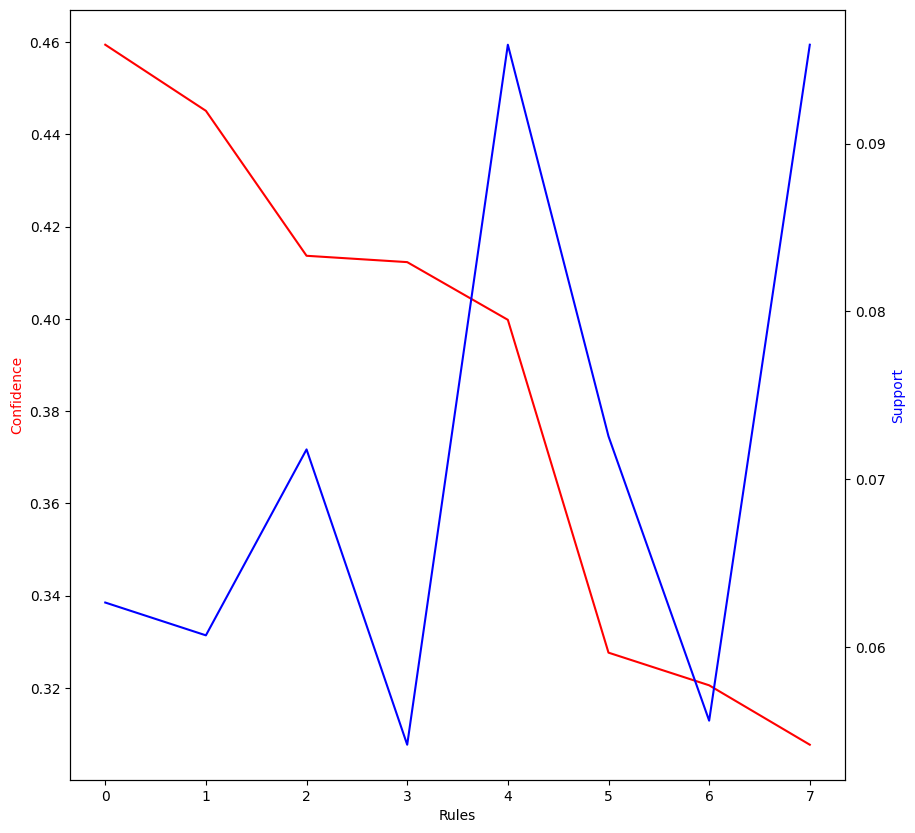

In [60]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(1,1, figsize=[10,10])

color="r"
ax1.plot(sorted_rules["confidence"], c=color)
ax1.set_xlabel("Rules")
ax1.set_ylabel("Confidence", c=color)

color="b"
ax2 = ax1.twinx()
ax2.plot(sorted_rules["support"], c=color)
ax2.set_ylabel("Support", c=color)

plt.show()

# 9) scatter plot the rules by confidence and support, labelling the points   with   the   index   value   of   the   corresponding   rule

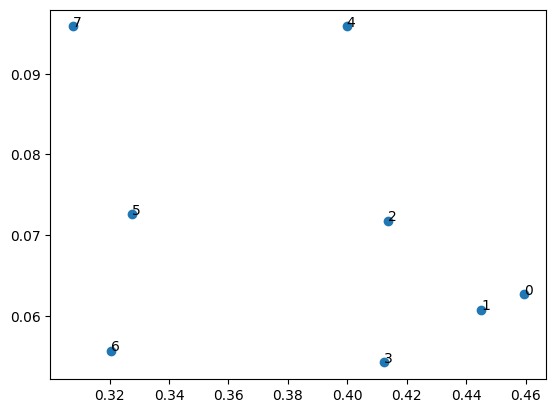

In [63]:
x=sorted_rules["confidence"]
y=sorted_rules["support"]

plt.scatter(x,y)
for i, txt in enumerate(sorted_rules.index):
    plt.annotate(txt, (x[i], y[i]))